In [1]:
import polars as pl
pl.Config.set_fmt_str_lengths(100)

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import numpy as np

In [ ]:
AJ = pl.scan_csv("../test_data/af2/positive_dimers/predictions/*/interfaces.csv").collect()
AJ

jobs,model_used,interface,iptm_ptm,iptm,ptm,confidence_score,pDockQ/mpDockQ,average_interface_pae,interface_average_plddt,interface_num_intf_residues,interface_polar,interface_hydrophobic,interface_charged,interface_contact_pairs,interface_score,interface_pDockQ2,interface_ipSAE,interface_LIS,interface_hb,interface_sb,interface_sc,interface_area,interface_solv_en
str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,f64,str,f64,i64,i64,f64,f64,f64
"""O00189+Q9UPM8""","""model_4_multimer_v3_pred_0""","""7_8""",0.666942,0.690995,0.570728,0.666942,0.732624,9.62859,81.584444,297,0.23569,0.407407,0.259259,780,235.949931,0.117428,"""0.5738060182746033""",0.270164,22,7,0.084435,4087.858368,-29.43258
"""O00212+Q9HAD4""","""model_2_multimer_v3_pred_0""","""9_A""",0.305816,0.226044,0.624905,0.305816,0.655455,21.953125,73.911374,131,0.236641,0.351145,0.282443,384,191.011472,0.011432,"""nan""",0.0,13,1,0.06069,1745.289481,-12.566084
"""O00541+Q14684""","""model_2_multimer_v3_pred_0""","""9_A""",0.240661,0.194502,0.425297,0.240661,0.102956,26.084737,57.544133,75,0.266667,0.36,0.28,95,113.806391,0.008994,"""nan""",0.0,0,0,0.098811,297.896019,-2.144851
"""O14544+Q86XK2""","""model_4_multimer_v3_pred_0""","""7_8""",0.317169,0.254619,0.567369,0.317169,0.669342,23.205435,64.817791,326,0.331288,0.276074,0.226994,1012,194.789164,0.010197,"""nan""",0.0,78,25,0.046379,5556.686024,-40.008139
"""O14641+P10515""","""model_1_multimer_v3_pred_0""","""A_B""",0.210637,0.190665,0.290526,0.210637,0.573429,27.705257,56.830771,350,0.26,0.337143,0.248571,1227,175.541419,0.008787,"""nan""",0.0,106,1,0.039184,6106.357673,-43.965775
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9UQ80+P06400""","""model_3_multimer_v3_pred_0""","""8_9""",0.271582,0.198553,0.563697,0.271582,0.690879,27.131204,73.819717,212,0.273585,0.311321,0.325472,548,202.176006,0.009465,"""nan""",0.0,59,9,0.027425,3304.524294,-23.792575
"""Q9UQB8+O14910""","""model_3_multimer_v3_pred_0""","""8_9""",0.206943,0.165611,0.37227,0.206943,0.216832,27.027455,56.986729,107,0.345794,0.411215,0.168224,224,133.932947,0.008851,"""nan""",0.0,13,0,0.069311,1320.54261,-9.507907
"""Q9Y2D8+Q96JH7""","""model_1_multimer_v3_pred_0""","""A_B""",0.363472,0.342621,0.446876,0.363472,0.548879,25.830796,52.044075,557,0.238779,0.339318,0.321364,2023,172.057499,0.009143,"""0.0323062470121404""",0.177817,205,39,0.031284,12839.906134,-92.447324


In [ ]:
CCP4 = pl.read_csv("../test_data/af2/positive_dimers/benchmarks/CCP4.csv")
CCP4

complex,interface_name,int_area,pvalue,int_solv_en,hb,sb
str,str,f64,f64,f64,i64,i64
"""O00189+Q9UPM8""","""7_8""",2102.27,0.23,-21.94,7,4
"""O00212+Q9HAD4""","""9_A""",892.16,0.23,-10.97,4,1
"""O00541+Q14684""","""9_A""",182.98,0.49,-1.5,0,0
"""O14544+Q86XK2""","""7_8""",2850.76,0.5,-18.04,24,14
"""O14641+P10515""","""A_B""",3097.67,0.45,-24.4,38,2
…,…,…,…,…,…,…
"""Q9UQ80+P06400""","""8_9""",1689.45,0.45,-6.7,6,5
"""Q9UQB8+O14910""","""8_9""",688.14,0.73,-1.63,6,0
"""Q9Y2D8+Q96JH7""","""A_B""",6598.27,0.63,-40.99,50,24


In [4]:
column_mapping = {
        "interface_hb": "hb",
        "interface_sb": "sb",
        "interface_solv_en": "int_solv_en",
        "interface_area": "int_area"}

In [5]:
#aj_cols = list(column_mapping.values())
#CCP4 = CCP4.select(aj_cols)
    
rename_map = {v: k for k, v in column_mapping.items() if k != v}
if rename_map:
    CCP4 = CCP4.rename(rename_map)

In [6]:
df = AJ.join(CCP4, left_on="jobs", right_on="complex")
df

jobs,model_used,interface,iptm_ptm,iptm,ptm,confidence_score,pDockQ/mpDockQ,average_interface_pae,interface_average_plddt,interface_num_intf_residues,interface_polar,interface_hydrophobic,interface_charged,interface_contact_pairs,interface_score,interface_pDockQ2,interface_ipSAE,interface_LIS,interface_hb,interface_sb,interface_sc,interface_area,interface_solv_en,interface_name,interface_area_right,pvalue,interface_solv_en_right,interface_hb_right,interface_sb_right
str,str,str,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,f64,f64,str,f64,i64,i64,f64,f64,f64,str,f64,f64,f64,i64,i64
"""O00189+Q9UPM8""","""model_4_multimer_v3_pred_0""","""7_8""",0.666942,0.690995,0.570728,0.666942,0.732624,9.62859,81.584444,297,0.23569,0.407407,0.259259,780,235.949931,0.117428,"""0.5738060182746033""",0.270164,22,7,0.084435,4087.858368,-29.43258,"""7_8""",2102.27,0.23,-21.94,7,4
"""O00212+Q9HAD4""","""model_2_multimer_v3_pred_0""","""9_A""",0.305816,0.226044,0.624905,0.305816,0.655455,21.953125,73.911374,131,0.236641,0.351145,0.282443,384,191.011472,0.011432,"""nan""",0.0,13,1,0.06069,1745.289481,-12.566084,"""9_A""",892.16,0.23,-10.97,4,1
"""O00541+Q14684""","""model_2_multimer_v3_pred_0""","""9_A""",0.240661,0.194502,0.425297,0.240661,0.102956,26.084737,57.544133,75,0.266667,0.36,0.28,95,113.806391,0.008994,"""nan""",0.0,0,0,0.098811,297.896019,-2.144851,"""9_A""",182.98,0.49,-1.5,0,0
"""O14544+Q86XK2""","""model_4_multimer_v3_pred_0""","""7_8""",0.317169,0.254619,0.567369,0.317169,0.669342,23.205435,64.817791,326,0.331288,0.276074,0.226994,1012,194.789164,0.010197,"""nan""",0.0,78,25,0.046379,5556.686024,-40.008139,"""7_8""",2850.76,0.5,-18.04,24,14
"""O14641+P10515""","""model_1_multimer_v3_pred_0""","""A_B""",0.210637,0.190665,0.290526,0.210637,0.573429,27.705257,56.830771,350,0.26,0.337143,0.248571,1227,175.541419,0.008787,"""nan""",0.0,106,1,0.039184,6106.357673,-43.965775,"""A_B""",3097.67,0.45,-24.4,38,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9UQ80+P06400""","""model_3_multimer_v3_pred_0""","""8_9""",0.271582,0.198553,0.563697,0.271582,0.690879,27.131204,73.819717,212,0.273585,0.311321,0.325472,548,202.176006,0.009465,"""nan""",0.0,59,9,0.027425,3304.524294,-23.792575,"""8_9""",1689.45,0.45,-6.7,6,5
"""Q9UQB8+O14910""","""model_3_multimer_v3_pred_0""","""8_9""",0.206943,0.165611,0.37227,0.206943,0.216832,27.027455,56.986729,107,0.345794,0.411215,0.168224,224,133.932947,0.008851,"""nan""",0.0,13,0,0.069311,1320.54261,-9.507907,"""8_9""",688.14,0.73,-1.63,6,0
"""Q9Y2D8+Q96JH7""","""model_1_multimer_v3_pred_0""","""A_B""",0.363472,0.342621,0.446876,0.363472,0.548879,25.830796,52.044075,557,0.238779,0.339318,0.321364,2023,172.057499,0.009143,"""0.0323062470121404""",0.177817,205,39,0.031284,12839.906134,-92.447324,"""A_B""",6598.27,0.63,-40.99,50,24


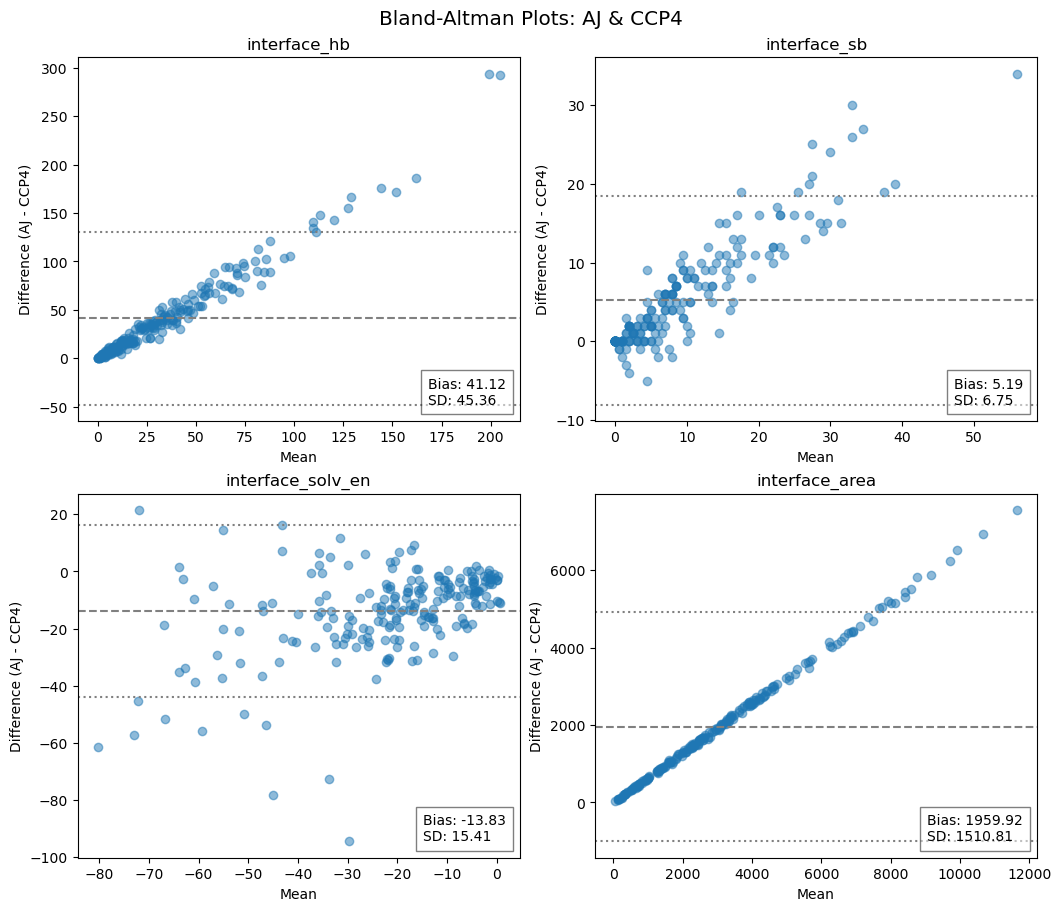

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 9), layout="constrained")
n = 0

for score in column_mapping.keys():
    # Get matched columns
    col_aj = score
    col_ccp4 = score + "_right"
    
    # Extract data
    data_aj = df[col_aj].to_numpy()
    data_ccp4 = df[col_ccp4].to_numpy()
    
    # Bland-Altman stats
    means = (data_aj + data_ccp4) / 2
    diffs = data_aj - data_ccp4
    bias = np.mean(diffs)
    sd = np.std(diffs, ddof=1)
    loa_u = bias + 1.96 * sd
    loa_l = bias - 1.96 * sd
    
    # Plot
    ax = axs.flat[n]
    ax.scatter(x=means, y=diffs, alpha=0.5)
    
    # Lines
    ax.axhline(bias, color='gray', linestyle='--')
    ax.axhline(loa_u, color='gray', linestyle=':')
    ax.axhline(loa_l, color='gray', linestyle=':')
    
    # Annotations
    text_stats = f"Bias: {bias:.2f}\nSD: {sd:.2f}"
    text_box = AnchoredText(text_stats, frameon=True, loc=4, pad=0.5)
    plt.setp(text_box.patch, facecolor='white', alpha=0.5)
    ax.add_artist(text_box)
    
    ax.set_title(score)
    ax.set_xlabel('Mean')
    ax.set_ylabel('Difference (AJ - CCP4)')
        
    n += 1

fig.suptitle("Bland-Altman Plots: AJ & CCP4", fontsize="x-large")
fig.savefig("figures/Bland_Altman_AJ_CCP4.png")
plt.show()

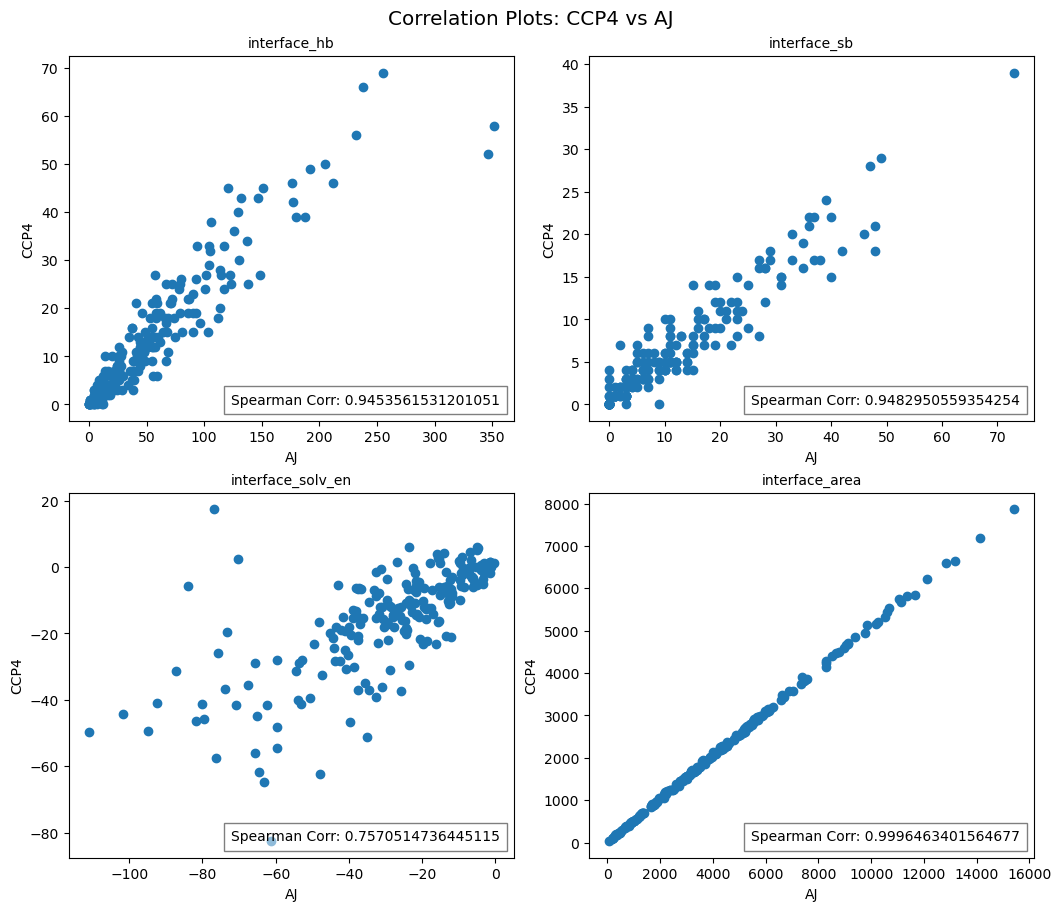

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 9), layout="constrained")
n = 0

for score in column_mapping.keys():
    axs.flat[n].scatter(x=df[score], y=df[score+"_right"])
    axs.flat[n].set_title(score, fontsize='medium', loc='center')
    
    corr = df.select(pl.corr(score, score+"_right", method="spearman")).item()
    text_box = AnchoredText(f"Spearman Corr: {corr}", frameon=True, loc=4, pad=0.5)
    plt.setp(text_box.patch, facecolor='white', alpha=0.5)
    axs.flat[n].add_artist(text_box)
    axs.flat[n].set_xlabel('AJ')
    axs.flat[n].set_ylabel('CCP4')
    
    n += 1

#fig.supxlabel('AJ', fontsize='large')
#fig.supylabel('CCP4', fontsize='large')
fig.suptitle("Correlation Plots: CCP4 vs AJ", fontsize="x-large")
fig.savefig('figures/Correlation_CCP4_vs_AJ.png')

plt.show()